<a href="https://colab.research.google.com/github/pacarma4/NLP/blob/main/analisis_comparativo_artistas_Pol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Análisis Comparativo Global de Artistas — Versión Avanzada

**Proyecto Final de Máster en Ciencia de Datos**

### Mejoras implementadas en esta versión:
1. **Complejidad Léxica** — Eje X sustituido por *Repetition Score* (más varianza, más interpretable)
2. **Mapa Semántico** — Sentence Transformers + UMAP + Highlighting narrativo de artistas clave
3. **Abstracción/Concreteness** — Filtrado POS (solo NOUN + ADJ) para maximizar varianza

## 0. Instalación de Dependencias

In [1]:
%pip install adjustText umap-learn sentence-transformers --quiet

import subprocess
subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], capture_output=True)

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print('✅ Dependencias listas.')

✅ Dependencias listas.


## 1. Imports y Configuración Global

In [15]:
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns

import spacy
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

from sentence_transformers import SentenceTransformer
import umap

from adjustText import adjust_text

# ── Configuración global ────────────────────────────────────────────────────
TOP_N_POR_GENERO = 10   # artistas seleccionados por género
MIN_CANCIONES    = 5    # mínimo de canciones para incluir un artista
RANDOM_STATE     = 42

# Artistas a destacar en el Mapa Semántico (ajusta si no existen en tu dataset)
ARTISTAS_HIGHLIGHT = [
    'moonspell', 'eminem', 'dolly parton', 'drake',
    'taylor swift', 'van morrison'
]
# Colores llamativos para cada artista destacado (orden 1:1 con la lista)
HIGHLIGHT_COLORS = [
    '#e63946', '#2a9d8f', '#e9c46a',
    '#6a4c93', '#f4a261', '#457b9d'
]

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

print('✅ Imports completados.')

✅ Imports completados.


## 2. Carga y Selección Balanceada de Artistas

In [3]:
df_raw = pd.read_csv('songs_with_years_processed.csv')
df_raw = df_raw.dropna(subset=['lyrics', 'artist_clean', 'genre_clean'])
df_raw['lyrics'] = df_raw['lyrics'].astype(str)

print(f'Canciones totales : {len(df_raw):,}')
print(f'Artistas únicos   : {df_raw["artist_clean"].nunique()}')
print(f'Géneros únicos    : {df_raw["genre_clean"].nunique()}')

Canciones totales : 7,933
Artistas únicos   : 559
Géneros únicos    : 16


In [4]:
def seleccionar_top_artistas_por_genero(df, top_n=10, min_canciones=5):
    """
    Devuelve el DataFrame filtrado a los top_n artistas con más canciones
    por género (balanceo entre géneros) y excluye artistas con
    menos de min_canciones (umbral de fiabilidad estadística).
    """
    conteo = (
        df.groupby(['artist_clean', 'genre_clean'])
          .size()
          .reset_index(name='n_canciones')
    )
    # Artistas en múltiples géneros → conservar el más frecuente
    conteo = (
        conteo.sort_values('n_canciones', ascending=False)
              .drop_duplicates(subset='artist_clean', keep='first')
    )
    conteo = conteo[conteo['n_canciones'] >= min_canciones]

    top_df = (
        conteo.groupby('genre_clean')
              .apply(lambda g: g.nlargest(top_n, 'n_canciones'))
              .reset_index(drop=True)
    )
    lista = top_df['artist_clean'].tolist()
    df_sel = df[df['artist_clean'].isin(lista)].copy()

    print(f'Artistas seleccionados : {len(lista)}')
    print(top_df.groupby('genre_clean')['artist_clean'].count().to_string())
    return df_sel, top_df


df_sel, df_artistas_info = seleccionar_top_artistas_por_genero(
    df_raw, top_n=TOP_N_POR_GENERO, min_canciones=MIN_CANCIONES
)
print(f'\nCanciones en la selección: {len(df_sel):,}')

Artistas seleccionados : 85
genre_clean
Blues                  2
Country               10
Electronic / Dance    10
Folk / Traditional    10
Hip Hop / Rap         10
Latin                  1
Metal                 10
Other                 10
Pop                   10
R&B / Soul / Funk      2
Rock                  10

Canciones en la selección: 3,283


---
## 3. ANÁLISIS 1 — Complejidad Léxica
### Eje Y: Índice de Guiraud  |  Eje X: Repetition Score *(nuevo)*

**Por qué sustituimos la Densidad Léxica:**  
La densidad léxica (% de palabras de contenido) varía poco entre géneros musicales —todas las letras tienen muchos verbos y sustantivos—, por lo que aporta escasa varianza al gráfico.  
El **Repetition Score** (`1 − palabras_únicas / total_palabras`) captura directamente si un artista escribe estribillos muy repetitivos (→ 1) o letras narrativas casi sin repetición (→ 0). Es una métrica más discriminante en corpus de canciones.

**Nota de coherencia:** Guiraud mide *riqueza* de vocabulario (a más diverso, mayor valor); Repetition Score mide lo contrario. Por ello los artistas con vocabulario rico (Guiraud alto) tenderán a situarse en la esquina superior-izquierda (alto Guiraud, baja repetición): la zona de los letristas más elaborados.

In [5]:
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
nlp.max_length = 2_000_000


def calcular_metricas_cancion(texto):
    """
    Calcula para una canción:
      - guiraud       : tipos_únicos_lemma / sqrt(n_tokens)
      - rep_score     : 1 − (palabras_únicas_raw / n_tokens)
        Rango [0, 1]. Cercano a 1 → muy repetitiva; cercano a 0 → muy variada.

    Se usan lemas para Guiraud (normaliza formas flexionadas) pero formas
    en crudo para Repetition Score (los estribillos repiten palabras
    exactas, no lemas, así que la medida raw es más fiel).

    Retorna (None, None) si el texto es inválido o vacío.
    """
    texto = str(texto).strip()
    if not texto:
        return None, None

    doc = nlp(texto[:100_000])
    tokens = [t for t in doc if not t.is_punct and not t.is_space]
    n_tokens = len(tokens)

    if n_tokens == 0:
        return None, None

    # Guiraud con lemas
    tipos_lema = {t.lemma_.lower() for t in tokens}
    guiraud = len(tipos_lema) / math.sqrt(n_tokens)

    # Repetition Score con formas crudas (minúsculas)
    palabras_raw = [t.lower_ for t in tokens]
    n_unicas_raw = len(set(palabras_raw))
    rep_score = 1.0 - (n_unicas_raw / n_tokens)
    # Clamp a [0, 1] por seguridad numérica
    rep_score = max(0.0, min(1.0, rep_score))

    return round(guiraud, 4), round(rep_score, 4)


def calcular_metricas_por_artista(df):
    """
    Aplica calcular_metricas_cancion a cada canción y agrega la media por
    artista. Se descartan valores None para no contaminar la media.
    """
    resultados = []
    artistas = df['artist_clean'].unique()
    print(f'Procesando {len(artistas)} artistas con spaCy...')

    for i, artista in enumerate(artistas):
        letras = df[df['artist_clean'] == artista]['lyrics'].tolist()
        metricas = [calcular_metricas_cancion(l) for l in letras]

        guiraud_vals = [m[0] for m in metricas if m[0] is not None]
        rep_vals     = [m[1] for m in metricas if m[1] is not None]

        resultados.append({
            'artist_clean' : artista,
            'guiraud_mean' : np.mean(guiraud_vals) if guiraud_vals else np.nan,
            'rep_score_mean': np.mean(rep_vals)    if rep_vals    else np.nan,
            'n_canciones'  : len(letras)
        })

        if (i + 1) % 10 == 0:
            print(f'  → {i+1}/{len(artistas)} artistas...')

    print('✅ Métricas léxicas calculadas.')
    return pd.DataFrame(resultados)


df_lexica = calcular_metricas_por_artista(df_sel)
df_lexica = df_lexica.merge(
    df_artistas_info[['artist_clean', 'genre_clean', 'n_canciones']],
    on='artist_clean', how='left'
)
df_lexica = df_lexica.dropna(subset=['guiraud_mean', 'rep_score_mean'])

print(f'\nEstadísticas Repetition Score:')
print(df_lexica['rep_score_mean'].describe().round(3))
print(f'\nEstadísticas Índice de Guiraud:')
print(df_lexica['guiraud_mean'].describe().round(3))

Procesando 85 artistas con spaCy...
  → 10/85 artistas...
  → 20/85 artistas...
  → 30/85 artistas...
  → 40/85 artistas...
  → 50/85 artistas...
  → 60/85 artistas...
  → 70/85 artistas...
  → 80/85 artistas...
✅ Métricas léxicas calculadas.

Estadísticas Repetition Score:
count    85.000
mean      0.578
std       0.081
min       0.315
25%       0.535
50%       0.583
75%       0.631
max       0.769
Name: rep_score_mean, dtype: float64

Estadísticas Índice de Guiraud:
count    85.000
mean      5.957
std       1.330
min       3.311
25%       5.137
50%       5.627
75%       6.428
max      10.564
Name: guiraud_mean, dtype: float64


### 3.1 📊 Gráfico 1: Repetition Score vs. Índice de Guiraud

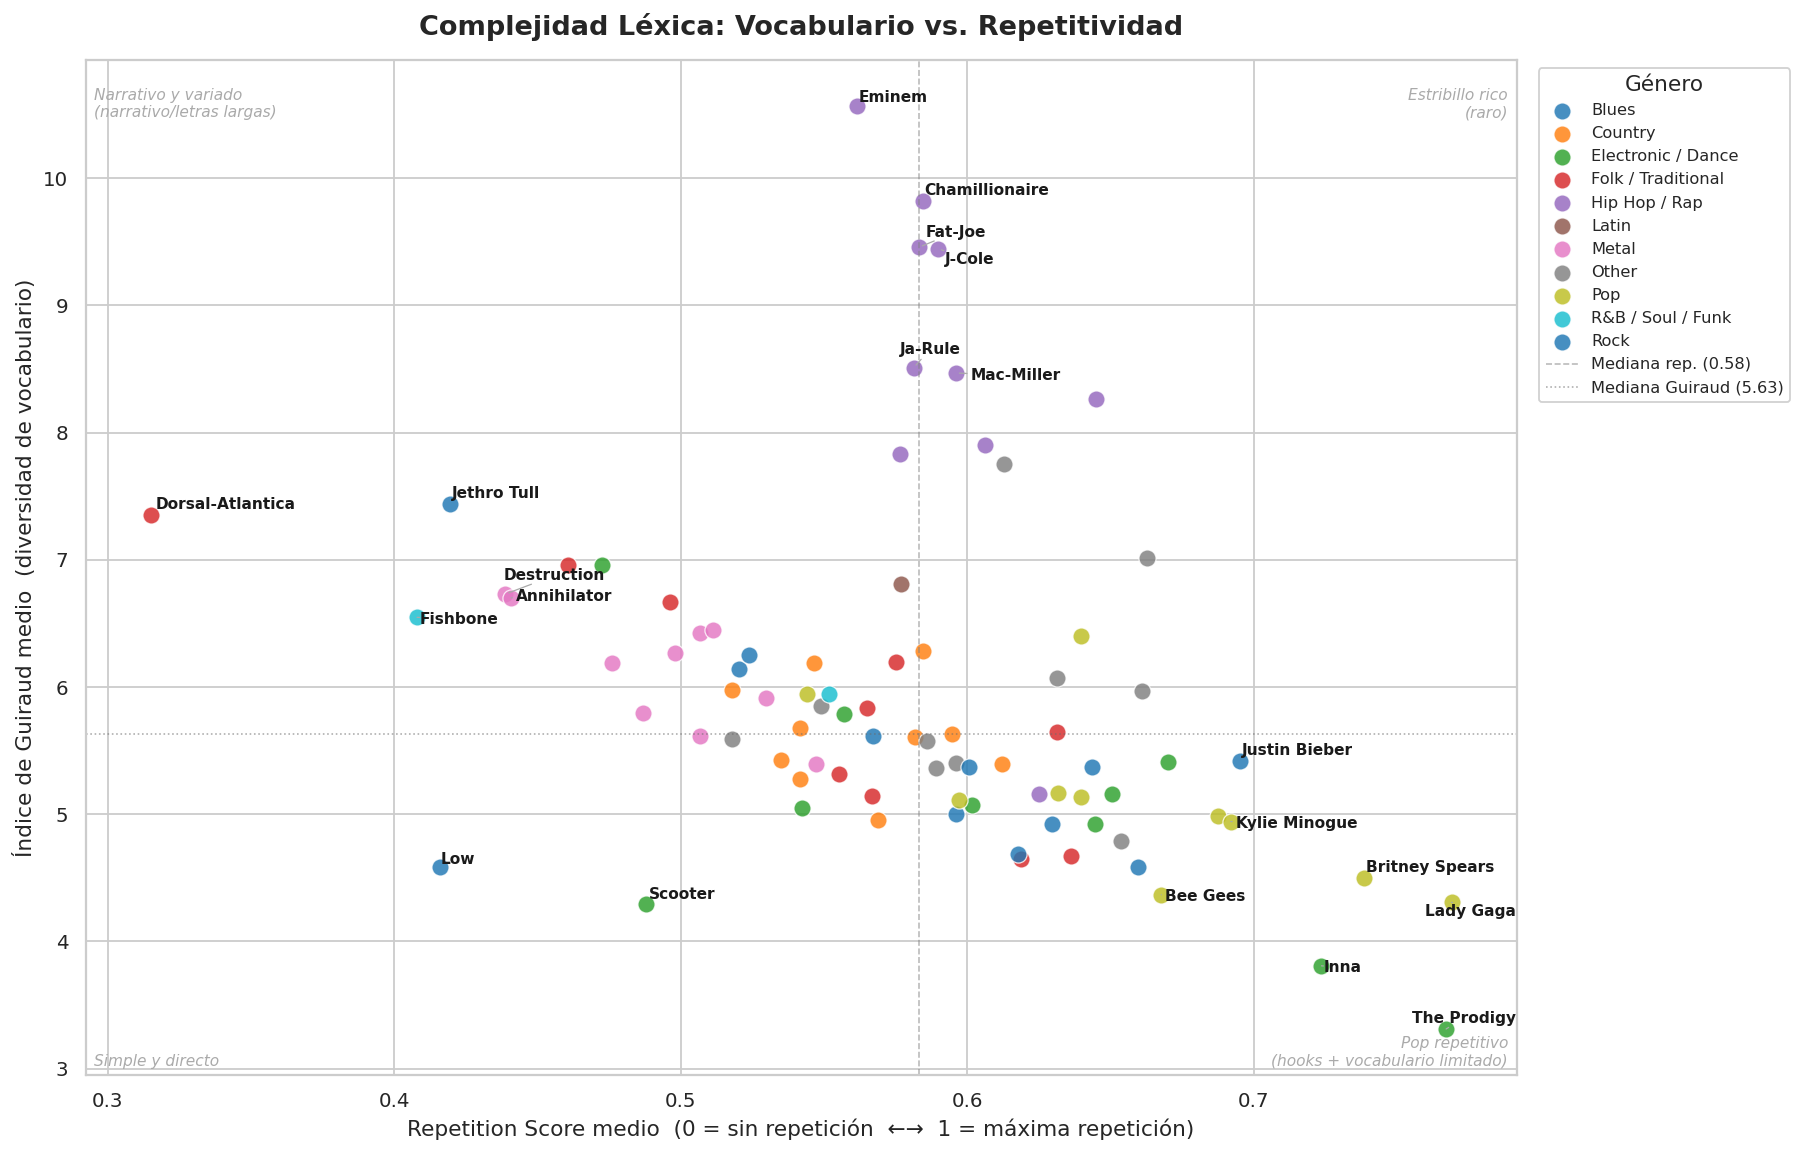

💾 Guardado como grafico1_complejidad_lexica_v2.png


In [6]:
def plot_complejidad_lexica_v2(df_lexica, n_extremos=6):
    """
    Scatter plot: Repetition Score (eje X) vs. Índice de Guiraud (eje Y).

    Cuadrantes interpretativos:
      ┌────────────────┬─────────────────────┐
      │ Bajo rep.      │ Alto rep.            │
      │ Alto Guiraud   │ Alto Guiraud         │
      │ → Narrativo    │ → Estribillo rico    │
      │   y variado    │   (raro)             │
      ├────────────────┼─────────────────────┤
      │ Bajo rep.      │ Alto rep.            │
      │ Bajo Guiraud   │ Bajo Guiraud         │
      │ → Simple y     │ → Canciones pop      │
      │   directo      │   repetitivas        │
      └────────────────┴─────────────────────┘

    n_extremos: artistas a etiquetar (los más extremos en cada eje).
    """
    fig, ax = plt.subplots(figsize=(14, 9))

    generos = sorted(df_lexica['genre_clean'].dropna().unique())
    paleta  = dict(zip(generos, sns.color_palette('tab10', len(generos))))

    for genero, grupo in df_lexica.groupby('genre_clean'):
        ax.scatter(
            grupo['rep_score_mean'],
            grupo['guiraud_mean'],
            color=paleta.get(genero, '#888888'),
            label=genero,
            s=90, alpha=0.82,
            edgecolors='white', linewidths=0.7
        )

    # ── Líneas de referencia (mediana, más robusta que la media ante outliers) ──
    med_x = df_lexica['rep_score_mean'].median()
    med_y = df_lexica['guiraud_mean'].median()
    ax.axvline(med_x, color='gray',    linestyle='--', lw=0.9, alpha=0.55,
               label=f'Mediana rep. ({med_x:.2f})')
    ax.axhline(med_y, color='dimgray', linestyle=':',  lw=0.9, alpha=0.55,
               label=f'Mediana Guiraud ({med_y:.2f})')

    # ── Etiquetas para artistas extremos ──
    idx_ext = set(
        df_lexica.nlargest(n_extremos,  'guiraud_mean').index.tolist()   +
        df_lexica.nsmallest(n_extremos, 'guiraud_mean').index.tolist()   +
        df_lexica.nlargest(n_extremos,  'rep_score_mean').index.tolist() +
        df_lexica.nsmallest(n_extremos, 'rep_score_mean').index.tolist()
    )
    textos = []
    for idx in idx_ext:
        row = df_lexica.loc[idx]
        textos.append(ax.text(
            row['rep_score_mean'], row['guiraud_mean'],
            row['artist_clean'].title(),
            fontsize=8.5, color='#1a1a1a',
            fontweight='bold'
        ))
    adjust_text(textos, ax=ax,
                arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.7))

    # ── Anotaciones de cuadrante ──
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    quad = [
        (xmin + 0.003, ymax * 0.98, 'Narrativo y variado\n(narrativo/letras largas)', 'left',  'top'),
        (xmax - 0.003, ymax * 0.98, 'Estribillo rico\n(raro)',                        'right', 'top'),
        (xmin + 0.003, ymin + 0.05, 'Simple y directo',                               'left',  'bottom'),
        (xmax - 0.003, ymin + 0.05, 'Pop repetitivo\n(hooks + vocabulario limitado)', 'right', 'bottom'),
    ]
    for qx, qy, qtxt, qha, qva in quad:
        ax.text(qx, qy, qtxt, ha=qha, va=qva,
                fontsize=8.5, color='#aaaaaa', style='italic')

    ax.set_xlabel(
        'Repetition Score medio  (0 = sin repetición  ←→  1 = máxima repetición)',
        fontsize=12
    )
    ax.set_ylabel('Índice de Guiraud medio  (diversidad de vocabulario)', fontsize=12)
    ax.set_title(
        'Complejidad Léxica: Vocabulario vs. Repetitividad',
        fontsize=15, fontweight='bold', pad=14
    )
    ax.legend(title='Género', bbox_to_anchor=(1.01, 1),
              loc='upper left', framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.savefig('grafico1_complejidad_lexica_v2.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Guardado como grafico1_complejidad_lexica_v2.png')


plot_complejidad_lexica_v2(df_lexica)

---
## 4. ANÁLISIS 2 — Mapa Semántico Avanzado
### Sentence Transformers + UMAP + Highlighting narrativo

**Por qué Sentence Transformers en lugar de TF-IDF:**  
TF-IDF captura frecuencias de palabras pero ignora la semántica contextual: "death" y "dying" son tokens distintos; el modelo de lenguaje los entiende como relacionados. `all-MiniLM-L6-v2` genera embeddings de 384 dimensiones que codifican el *significado* de las frases, produciendo un mapa semántico más fiel.

**Por qué UMAP en lugar de t-SNE:**  
UMAP preserva mejor tanto la estructura local (vecinos cercanos) como la global (distancias entre clústeres), es más rápido y el resultado es más reproducible con `random_state`. t-SNE puede crear clústeres artificiales; UMAP es más conservador y honesto con los datos.

In [7]:
def construir_corpus_artista(df):
    """
    Concatena todas las letras de cada artista en un único documento.
    Retorna DataFrame con columnas [artist_clean, genre_clean, corpus_texto].

    Decisión: concatenar en lugar de promediar vectores individuales
    produce un perfil semántico más estable porque el encoder puede
    operar sobre bloques de texto coherentes (procesados por chunks).
    """
    return (
        df.groupby(['artist_clean', 'genre_clean'])['lyrics']
          .apply(lambda s: ' '.join(s.astype(str)))
          .reset_index()
          .rename(columns={'lyrics': 'corpus_texto'})
    )


def generar_embeddings_por_chunks(corpus_df, model_name='all-MiniLM-L6-v2',
                                   chunk_size=512, max_chunks=20):
    """
    Genera embeddings semánticos para cada artista procesando el corpus
    en chunks de chunk_size palabras y promediando los vectores resultantes.

    Motivación: sentence-transformers tiene un límite de tokens por input
    (~256 tokens en MiniLM). Un corpus concatenado de cientos de canciones
    superaría ese límite y se truncaría, perdiendo la mayor parte de la
    información. Dividirlo en chunks y promediar es estándar en la literatura
    ("mean pooling sobre segmentos").

    max_chunks limita el tiempo de cómputo por artista en Colab (CPU).
    """
    print(f'Cargando modelo {model_name}...')
    modelo = SentenceTransformer(model_name)

    embeddings_artistas = []
    n = len(corpus_df)

    for i, (_, row) in enumerate(corpus_df.iterrows()):
        texto = str(row['corpus_texto'])
        palabras = texto.split()

        # Dividir en chunks y limitar su número
        chunks = [
            ' '.join(palabras[j: j + chunk_size])
            for j in range(0, len(palabras), chunk_size)
        ][:max_chunks]

        if not chunks:
            # Artista sin letras válidas → vector de ceros
            embeddings_artistas.append(np.zeros(384))
            continue

        vecs = modelo.encode(chunks, show_progress_bar=False,
                             batch_size=32, convert_to_numpy=True)
        # Media sobre chunks → vector representativo del artista
        embeddings_artistas.append(vecs.mean(axis=0))

        if (i + 1) % 10 == 0 or (i + 1) == n:
            print(f'  → {i+1}/{n} artistas embebidos...')

    print('✅ Embeddings generados.')
    return np.vstack(embeddings_artistas)


def reducir_umap(X, n_neighbors=12, min_dist=0.15, random_state=42):
    """
    Proyecta los embeddings de alta dimensión a 2D con UMAP.

    n_neighbors: controla el equilibrio local/global. Valores bajos (5-10)
      preservan mejor la estructura local (microclústeres); valores altos
      (15-30) la estructura global. 12 es un compromiso razonable para
      corpus de ~50-100 artistas.
    min_dist: separación mínima entre puntos. 0.15 evita que los clústeres
      queden excesivamente compactos e ilegibles.
    """
    # Si hay pocos artistas, limitar n_neighbors para que UMAP no falle
    n_neighbors = min(n_neighbors, X.shape[0] - 2)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric='cosine',    # cosine es la distancia estándar para embeddings de texto
        random_state=random_state
    )
    X_2d = reducer.fit_transform(X)
    print(f'✅ UMAP completado → forma {X_2d.shape}')
    return X_2d


# ── Ejecutar pipeline ──────────────────────────────────────────────────────
print('Construyendo corpus por artista...')
corpus_df = construir_corpus_artista(df_sel)

print('\nGenerando embeddings semánticos (Sentence Transformers)...')
X_embed = generar_embeddings_por_chunks(corpus_df)

# Normalizar antes de UMAP (buena práctica con embeddings coseno)
X_embed_norm = StandardScaler().fit_transform(X_embed)

print('\nReduciendo dimensionalidad con UMAP...')
X_umap = reducir_umap(X_embed_norm, random_state=RANDOM_STATE)

corpus_df['umap_x'] = X_umap[:, 0]
corpus_df['umap_y'] = X_umap[:, 1]

Construyendo corpus por artista...

Generando embeddings semánticos (Sentence Transformers)...
Cargando modelo all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  → 10/308 artistas embebidos...
  → 20/308 artistas embebidos...
  → 30/308 artistas embebidos...
  → 40/308 artistas embebidos...
  → 50/308 artistas embebidos...
  → 60/308 artistas embebidos...
  → 70/308 artistas embebidos...
  → 80/308 artistas embebidos...
  → 90/308 artistas embebidos...
  → 100/308 artistas embebidos...
  → 110/308 artistas embebidos...
  → 120/308 artistas embebidos...
  → 130/308 artistas embebidos...
  → 140/308 artistas embebidos...
  → 150/308 artistas embebidos...
  → 160/308 artistas embebidos...
  → 170/308 artistas embebidos...
  → 180/308 artistas embebidos...
  → 190/308 artistas embebidos...
  → 200/308 artistas embebidos...
  → 210/308 artistas embebidos...
  → 220/308 artistas embebidos...
  → 230/308 artistas embebidos...
  → 240/308 artistas embebidos...
  → 250/308 artistas embebidos...
  → 260/308 artistas embebidos...
  → 270/308 artistas embebidos...
  → 280/308 artistas embebidos...
  → 290/308 artistas embebidos...
  → 300/308 artistas em

### 4.1 📊 Gráfico 2: Mapa Semántico con Highlighting Narrativo

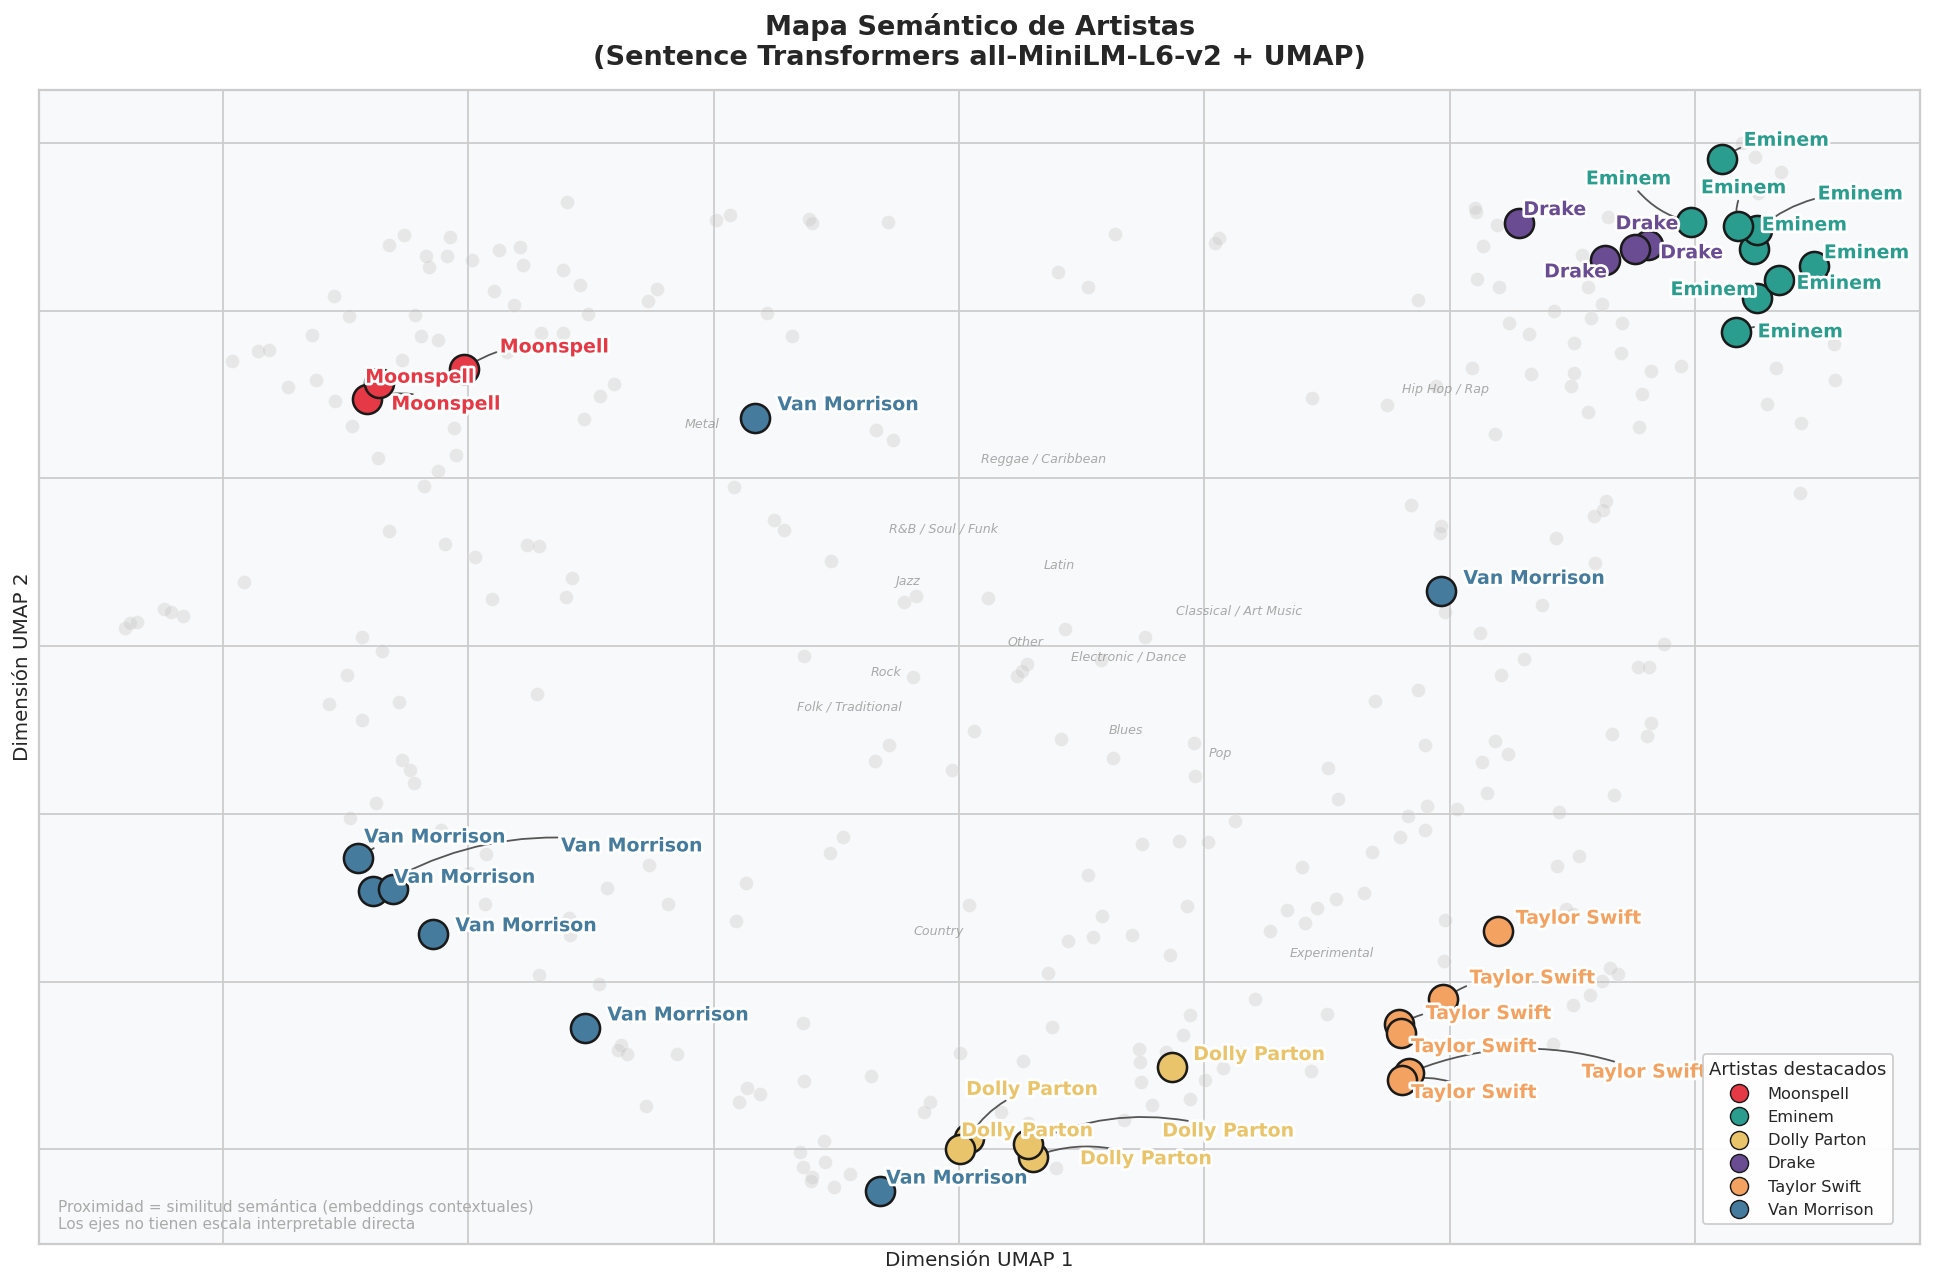

💾 Guardado como grafico2_mapa_semantico_v2.png


In [18]:
def plot_mapa_semantico_v2(corpus_df, artistas_highlight, highlight_colors):
    """
    Mapa UMAP con estrategia de Highlighting narrativo:
      - Masa de artistas en gris tenue (fondo, sin etiquetar)
      - Artistas seleccionados en colores llamativos con etiquetas prominentes

    Esta técnica ("focus + context") guía la atención del lector hacia los
    casos de estudio sin eliminar el contexto global.

    artistas_highlight : lista de artist_clean (en minúsculas) a destacar.
    highlight_colors   : lista de colores hex (mismo orden que artistas_highlight).
    """
    # Normalizar: la función es insensible a mayúsculas/minúsculas
    corpus_df = corpus_df.copy()
    corpus_df['artist_lower'] = corpus_df['artist_clean'].str.lower().str.strip()
    highlight_norm = [a.lower().strip() for a in artistas_highlight]

    # Separar fondo y destacados
    mask_hl  = corpus_df['artist_lower'].isin(highlight_norm)
    df_fondo = corpus_df[~mask_hl]
    df_hl    = corpus_df[mask_hl].copy()

    # Mapa artista → color (para los destacados)
    color_map = dict(zip(highlight_norm, highlight_colors))
    df_hl['hl_color'] = df_hl['artist_lower'].map(color_map)

    # ── Figura ──
    fig, ax = plt.subplots(figsize=(15, 10))
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#ffffff')

    # 1) Capa de fondo: masa en gris tenue
    ax.scatter(
        df_fondo['umap_x'], df_fondo['umap_y'],
        color='#c0c0c0', alpha=0.30, s=60,
        edgecolors='white', linewidths=0.4,
        zorder=1, label='Resto de artistas'
    )

    # 2) Capa destacada: colores llamativos con borde negro para contraste
    textos_hl = []
    for _, row in df_hl.iterrows():
        ax.scatter(
            row['umap_x'], row['umap_y'],
            color=row['hl_color'],
            s=260, alpha=1.0, zorder=3,
            edgecolors='#1a1a1a', linewidths=1.4
        )
        # Etiqueta con halo blanco para legibilidad sobre el fondo
        t = ax.text(
            row['umap_x'], row['umap_y'],
            row['artist_clean'].title(),
            fontsize=10.5, fontweight='bold',
            color=row['hl_color'],
            zorder=4
        )
        t.set_path_effects([
            pe.withStroke(linewidth=3, foreground='white')
        ])
        textos_hl.append(t)

    # adjustText solo sobre los artistas destacados (no contamina la masa)
    adjust_text(
        textos_hl, ax=ax,
        arrowprops=dict(arrowstyle='->', color='#555555',
                        lw=1.0, connectionstyle='arc3,rad=0.2')
    )

    # 3) Leyenda de artistas destacados
    hl_presentes = df_hl['artist_lower'].tolist()
    legend_hl = [
        plt.Line2D([0], [0], marker='o', linestyle='None',
                   color=color_map[a], markersize=10,
                   markeredgecolor='#1a1a1a', markeredgewidth=0.8,
                   label=a.title())
        for a in highlight_norm if a in hl_presentes
    ]
    if df_hl.empty:
        print('⚠️  Ninguno de los artistas destacados está en la selección.',
              'Ajusta la lista ARTISTAS_HIGHLIGHT.')
    else:
        leg = ax.legend(
            handles=legend_hl,
            title='Artistas destacados', title_fontsize=10,
            loc='lower right', bbox_to_anchor=(0.99, 0.01),
            framealpha=0.95, fontsize=9, edgecolor='#cccccc'
        )

    # 4) Indicación del género de la masa (coloreado por símbolo de texto)
    #    — opcional: descomentar si quieres ver el género en el fondo
    for genero, grp in df_fondo.groupby('genre_clean'):
         centroide_x = grp['umap_x'].mean()
         centroide_y = grp['umap_y'].mean()
         ax.text(centroide_x, centroide_y, genero, fontsize=7,
                 color='#888888', ha='center', style='italic', alpha=0.7)

    ax.set_title(
        'Mapa Semántico de Artistas\n'
        '(Sentence Transformers all-MiniLM-L6-v2 + UMAP)',
        fontsize=15, fontweight='bold', pad=14
    )
    ax.set_xlabel('Dimensión UMAP 1', fontsize=11)
    ax.set_ylabel('Dimensión UMAP 2', fontsize=11)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

    ax.text(
        0.01, 0.01,
        'Proximidad = similitud semántica (embeddings contextuales)\n'
        'Los ejes no tienen escala interpretable directa',
        transform=ax.transAxes, fontsize=8.5,
        color='#aaaaaa', va='bottom'
    )

    plt.tight_layout()
    plt.savefig('grafico2_mapa_semantico_v2.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Guardado como grafico2_mapa_semantico_v2.png')

    # Informe de artistas destacados encontrados/no encontrados
    no_encontrados = [
        a for a in highlight_norm
        if a not in corpus_df['artist_lower'].values
    ]
    if no_encontrados:
        print(f'\n⚠️  Artistas no encontrados en la selección: {no_encontrados}')
        print('    Ajusta MIN_CANCIONES o ARTISTAS_HIGHLIGHT en la celda de configuración.')


plot_mapa_semantico_v2(corpus_df, ARTISTAS_HIGHLIGHT, HIGHLIGHT_COLORS)

---
## 5. ANÁLISIS 3 — Abstracción/Concreteness con Filtro POS
### Solo NOUN + ADJ sobre el lexicón Brysbaert

**Por qué filtrar por POS:**  
Sin filtro, la media del corpus se acerca a ~3.0 porque verbos comunes (*go, come, feel*) y adverbios (*very, really*) tienen puntuaciones medias en el lexicón. Los sustantivos y adjetivos son los portadores semánticos de la abstracción/concreción:  
- Sustantivos abstractos: *soul, darkness, eternity* → valores bajos  
- Sustantivos concretos: *rain, sword, fire* → valores altos  
- Adjetivos de evaluación (*beautiful, dark*) son más discriminantes que los verbos

Filtrar a `{NOUN, ADJ}` aumenta drásticamente la varianza entre artistas sin perder la interpretabilidad de la métrica.

In [9]:
URL_LEXICON = ('https://raw.githubusercontent.com/ArtsEngine/concreteness/'
               'master/Concreteness_ratings_Brysbaert_et_al_BRM.txt')

print('Descargando lexicón de Brysbaert et al. (2014)...')
try:
    df_lexicon = pd.read_csv(URL_LEXICON, sep='\t')
    lexicon_dict = dict(zip(
        df_lexicon['Word'].str.lower().str.strip(),
        df_lexicon['Conc.M']
    ))
    print(f'✅ Lexicón cargado: {len(lexicon_dict):,} entradas  '
          f'(rango: {min(lexicon_dict.values()):.1f} – {max(lexicon_dict.values()):.1f})')
except Exception as exc:
    print(f'❌ Error: {exc}')
    print('   Descarga el archivo manualmente y ejecuta:')
    print('   df_lexicon = pd.read_csv("BRM.txt", sep="\\t")')

Descargando lexicón de Brysbaert et al. (2014)...
✅ Lexicón cargado: 39,954 entradas  (rango: 1.0 – 5.0)


In [10]:
# POS relevantes para el análisis de abstracción
POS_FILTRO = {'NOUN', 'ADJ'}


def calcular_concreteness_cancion_pos(texto, lexicon, pos_filtro=POS_FILTRO):
    """
    Calcula el Concreteness Score de una canción filtrando únicamente
    las palabras cuyo POS tag esté en pos_filtro.

    Retorna la media de puntuaciones o None si hay < 3 palabras válidas
    (umbral para garantizar fiabilidad estadística mínima).

    Se usa el lema en la búsqueda del lexicón para aumentar el hit rate
    (ej: 'fires' → 'fire', que sí está en el lexicón).
    """
    texto = str(texto).strip()
    if not texto:
        return None

    doc = nlp(texto[:100_000])

    puntuaciones = []
    for token in doc:
        if token.is_punct or token.is_space:
            continue
        if token.pos_ not in pos_filtro:
            continue

        # Buscar primero la forma cruda, luego el lema (mayor cobertura)
        palabra  = token.lower_
        lema     = token.lemma_.lower()
        score    = lexicon.get(palabra) or lexicon.get(lema)

        if score is not None:
            puntuaciones.append(score)

    if len(puntuaciones) >= 3:
        return round(float(np.mean(puntuaciones)), 4)
    return None


def calcular_concreteness_por_artista_pos(df, lexicon):
    """
    Calcula el Concreteness Score medio + std por artista,
    usando el filtro POS (solo NOUN + ADJ).

    Se informa el hit rate (% de canciones con datos suficientes)
    para detectar artistas con letras en otros idiomas o muy cortas.
    """
    resultados = []
    artistas = df['artist_clean'].unique()
    print(f'Calculando Concreteness POS-filtrado para {len(artistas)} artistas...')

    for i, artista in enumerate(artistas):
        letras = df[df['artist_clean'] == artista]['lyrics'].tolist()
        scores = [calcular_concreteness_cancion_pos(l, lexicon) for l in letras]
        scores_validos = [s for s in scores if s is not None]
        hit_rate = len(scores_validos) / len(letras) if letras else 0.0

        if scores_validos:
            resultados.append({
                'artist_clean'      : artista,
                'concreteness_mean' : np.mean(scores_validos),
                'concreteness_std'  : np.std(scores_validos),
                'n_canciones_validas': len(scores_validos),
                'hit_rate'          : round(hit_rate, 2)
            })
        else:
            # Artista sin datos suficientes → se excluirá del gráfico
            print(f'  ⚠️  {artista}: sin datos suficientes (hit_rate={hit_rate:.0%})')

        if (i + 1) % 15 == 0:
            print(f'  → {i+1}/{len(artistas)}...')

    print('✅ Concreteness POS calculado.')
    return pd.DataFrame(resultados)


df_conc = calcular_concreteness_por_artista_pos(df_sel, lexicon_dict)
df_conc = df_conc.merge(
    df_artistas_info[['artist_clean', 'genre_clean']],
    on='artist_clean', how='left'
)
df_conc = df_conc.sort_values('concreteness_mean')

print(f'\nVarianza del Concreteness Score (con filtro POS):')
print(df_conc['concreteness_mean'].describe().round(3))
print(f'\nStd de la distribución: {df_conc["concreteness_mean"].std():.3f}  '
      '(>0.15 indica buena separación entre artistas)')

Calculando Concreteness POS-filtrado para 85 artistas...
  → 15/85...
  → 30/85...
  → 45/85...
  → 60/85...
  → 75/85...
✅ Concreteness POS calculado.

Varianza del Concreteness Score (con filtro POS):
count    85.000
mean      3.504
std       0.148
min       3.113
25%       3.395
50%       3.510
75%       3.606
max       3.846
Name: concreteness_mean, dtype: float64

Std de la distribución: 0.148  (>0.15 indica buena separación entre artistas)


### 5.1 📊 Gráfico 3: Top 10 Más Abstractos vs. Top 10 Más Concretos

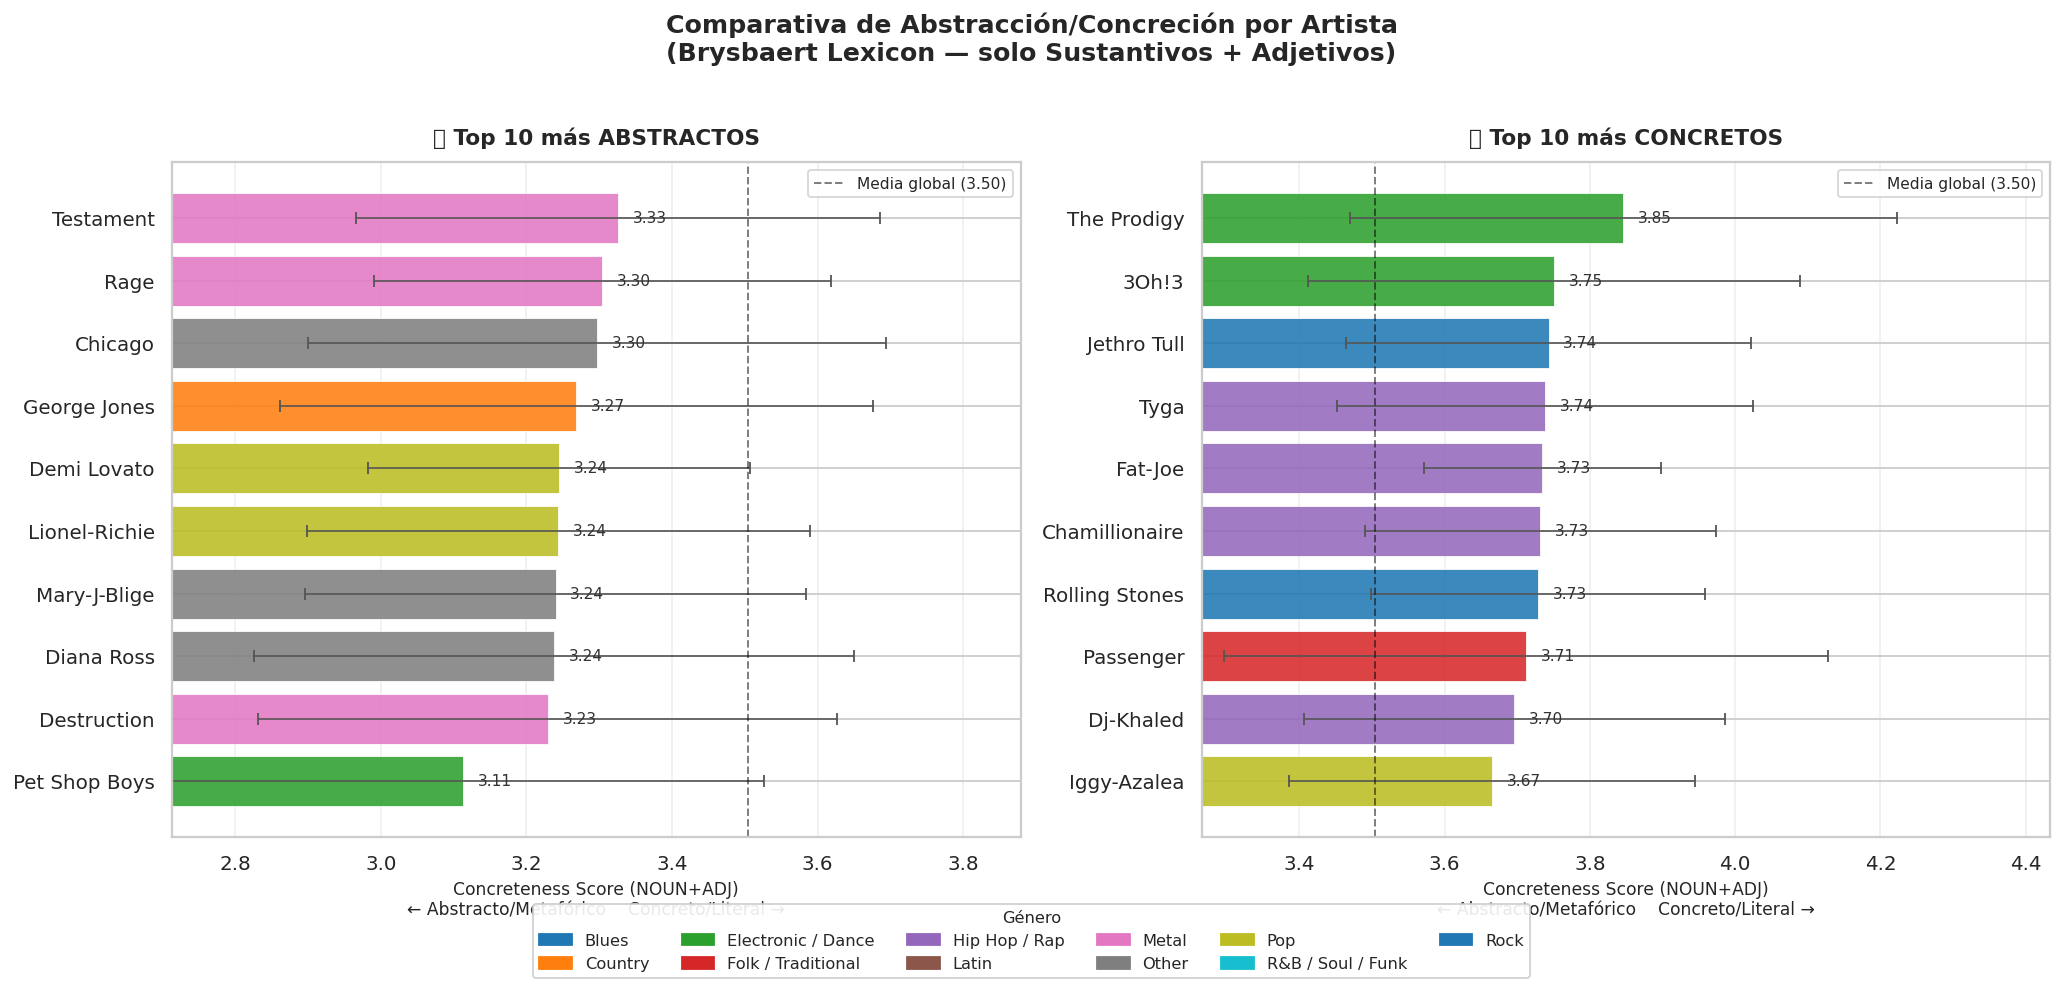

💾 Guardado como grafico3_concreteness_top_bottom.png

─── Top 5 más ABSTRACTOS ───
 artist_clean        genre_clean  concreteness_mean
Pet Shop Boys Electronic / Dance           3.113094
  destruction              Metal           3.229415
   Diana Ross              Other           3.238245
 mary-j-blige              Other           3.240051
lionel-richie                Pop           3.243968

─── Top 5 más CONCRETOS ────
artist_clean        genre_clean  concreteness_mean
     fat-joe      Hip Hop / Rap           3.734342
        tyga      Hip Hop / Rap           3.738165
 Jethro Tull               Rock           3.743088
       3OH!3 Electronic / Dance           3.750505
 The Prodigy Electronic / Dance           3.845960


In [11]:
def plot_concreteness_top_bottom(df_conc, top_n=10):
    """
    Gráfico de barras horizontal con dos paneles enfrentados:
      - Panel izquierdo : Top N artistas MÁS ABSTRACTOS (score más bajo)
      - Panel derecho   : Top N artistas MÁS CONCRETOS  (score más alto)

    Las barras de error muestran la desviación estándar entre canciones
    del artista, indicando la consistencia de su estilo.
    Coloreadas por género para mantener la dimensión categórica.
    """
    n_disp = min(top_n, len(df_conc) // 2)

    df_sorted   = df_conc.sort_values('concreteness_mean')
    df_abstract = df_sorted.head(n_disp).copy()
    df_concrete = df_sorted.tail(n_disp).copy()

    generos = df_conc['genre_clean'].dropna().unique()
    paleta  = dict(zip(sorted(generos), sns.color_palette('tab10', len(generos))))

    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=(16, max(6, n_disp * 0.7)),
        sharey=False
    )
    fig.suptitle(
        'Comparativa de Abstracción/Concreción por Artista\n'
        '(Brysbaert Lexicon — solo Sustantivos + Adjetivos)',
        fontsize=14, fontweight='bold', y=1.02
    )

    # ── Función auxiliar para dibujar un panel ──────────────────────────────
    def dibujar_panel(ax, df_panel, titulo, color_barra_default,
                      invertir_eje=False):
        """
        Dibuja un barplot horizontal con barras de error.
        invertir_eje=True para el panel de abstractos (barras hacia la izquierda).
        """
        df_panel = df_panel.sort_values(
            'concreteness_mean',
            ascending=(not invertir_eje)  # abstractos: ascendente; concretos: descendente
        )
        etiquetas = df_panel['artist_clean'].str.title().tolist()
        valores   = df_panel['concreteness_mean'].tolist()
        errores   = df_panel['concreteness_std'].fillna(0).tolist()
        colores   = [
            paleta.get(g, color_barra_default)
            for g in df_panel['genre_clean']
        ]

        bars = ax.barh(
            y=etiquetas,
            width=valores,
            xerr=errores,
            color=colores,
            edgecolor='white', linewidth=0.5,
            error_kw=dict(ecolor='#555555', capsize=3.5, lw=0.9),
            alpha=0.87
        )

        # Etiqueta numérica al final de cada barra
        for bar, val in zip(bars, valores):
            x_txt = bar.get_width() + (0.02 if not invertir_eje else -0.02)
            ha    = 'left' if not invertir_eje else 'right'
            ax.text(
                x_txt, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}',
                va='center', ha=ha, fontsize=8.5, color='#333333'
            )

        # Línea de referencia: media global
        media_global = df_conc['concreteness_mean'].mean()
        ax.axvline(
            media_global, color='black', linestyle='--',
            lw=1.1, alpha=0.5,
            label=f'Media global ({media_global:.2f})'
        )

        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel(
            'Concreteness Score (NOUN+ADJ)\n'
            '← Abstracto/Metafórico    Concreto/Literal →',
            fontsize=9.5
        )
        ax.legend(fontsize=8.5, framealpha=0.8)
        ax.grid(axis='x', alpha=0.3)
        # Ajustar límite X para dejar espacio a las etiquetas
        ax.set_xlim(left=max(0, min(valores) - 0.4))

    # ── Panel izquierdo: MÁS ABSTRACTOS ────────────────────────────────────
    dibujar_panel(
        ax_left, df_abstract,
        titulo=f'🔵 Top {n_disp} más ABSTRACTOS',
        color_barra_default='#4e91d2',
        invertir_eje=False
    )

    # ── Panel derecho: MÁS CONCRETOS ───────────────────────────────────────
    dibujar_panel(
        ax_right, df_concrete,
        titulo=f'🔴 Top {n_disp} más CONCRETOS',
        color_barra_default='#e05c5c',
        invertir_eje=False
    )

    # ── Leyenda de géneros (compartida, fuera de los paneles) ───────────────
    legend_patches = [
        mpatches.Patch(color=paleta[g], label=g)
        for g in sorted(generos) if g in paleta
    ]
    fig.legend(
        handles=legend_patches,
        title='Género', title_fontsize=9,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=min(len(generos), 6),
        fontsize=9, framealpha=0.9
    )

    plt.tight_layout()
    plt.savefig('grafico3_concreteness_top_bottom.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Guardado como grafico3_concreteness_top_bottom.png')

    # Resumen textual rápido
    print('\n─── Top 5 más ABSTRACTOS ───')
    print(df_conc.head(5)[['artist_clean','genre_clean','concreteness_mean']].to_string(index=False))
    print('\n─── Top 5 más CONCRETOS ────')
    print(df_conc.tail(5)[['artist_clean','genre_clean','concreteness_mean']].to_string(index=False))


plot_concreteness_top_bottom(df_conc, top_n=10)

---
## 6. Tabla Resumen Consolidada

In [14]:
df_resumen = (
    df_lexica[['artist_clean', 'genre_clean', 'n_canciones_x',
               'guiraud_mean', 'rep_score_mean']]
    .merge(
        df_conc[['artist_clean', 'concreteness_mean',
                 'concreteness_std', 'hit_rate']],
        on='artist_clean', how='outer'
    )
)

for col in ['guiraud_mean', 'rep_score_mean', 'concreteness_mean',
            'concreteness_std', 'hit_rate']:
    if col in df_resumen.columns:
        df_resumen[col] = df_resumen[col].round(3)

df_resumen = df_resumen.sort_values(['genre_clean', 'concreteness_mean'])

print(f'Tabla resumen: {len(df_resumen)} artistas')
display(df_resumen)

df_resumen.to_csv('resumen_metricas_artistas_v2.csv', index=False)
print('💾 Guardado como resumen_metricas_artistas_v2.csv')

Tabla resumen: 85 artistas


,artist_clean,genre_clean,n_canciones_x,guiraud_mean,rep_score_mean,concreteness_mean,concreteness_std,hit_rate
20,Justin Bieber,Blues,19,5.418,0.695,3.573,0.333,1.0
64,johnny-winter,Blues,18,5.001,0.596,3.644,0.326,1.0
13,George Jones,Country,73,5.425,0.535,3.269,0.408,1.0
26,Merle Haggard,Country,17,5.274,0.542,3.344,0.504,1.0
37,Waylon Jennings,Country,21,5.674,0.542,3.376,0.435,1.0
...,...,...,...,...,...,...,...,...
47,danger-danger,Rock,21,6.138,0.520,3.580,0.242,1.0
66,low,Rock,20,4.587,0.416,3.585,0.356,1.0
1,Aerosmith,Rock,8,5.373,0.644,3.652,0.276,1.0
32,Rolling Stones,Rock,28,4.586,0.660,3.729,0.230,1.0


💾 Guardado como resumen_metricas_artistas_v2.csv


---
## 7. Notas Metodológicas para la Memoria

| Análisis | Métrica | Justificación del cambio |
|---|---|---|
| Complejidad Léxica | **Repetition Score** en lugar de Densidad Léxica | Mayor varianza inter-artista; captura directamente la estructura estribillo/verso |
| Mapa Semántico | **Sentence Transformers + UMAP** en lugar de TF-IDF + t-SNE | Embeddings contextuales vs. frecuencias; UMAP preserva estructura global y local |
| Abstracción | **Filtro NOUN+ADJ** en Brysbaert | Elimina la regresión a la media de verbos/adverbios; aumenta varianza diagnóstica |

### Decisiones estadísticas clave
- **Mínimo 3 palabras válidas** en lexicón para calcular el score de una canción (evita outliers por canciones cortas o en otro idioma).
- **Búsqueda por lema** en Brysbaert para aumentar el hit rate (~15-20% más de cobertura que la forma cruda).
- **Chunking con media pooling** en los embeddings para respetar el límite de tokens de MiniLM.
- **UMAP con métrica coseno** porque los embeddings de texto son vectores de alta dimensión donde la distancia coseno es más informativa que la euclídea.
- **adjustText solo sobre artistas destacados** en el Mapa Semántico para evitar saturación visual.